# Data collection

## Import dataset from Kaggle
    Sign Language MNIST
    ASL Alphabet

In [1]:
#!pip install kagglehub

> MNIST



In [2]:
import kagglehub

# Download the latest version of the dataset
path = kagglehub.dataset_download("datamunge/sign-language-mnist")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\User\.cache\kagglehub\datasets\datamunge\sign-language-mnist\versions\1


## Load libraries

In [3]:
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
import os
from sklearn.model_selection import train_test_split

## Step 1 — Load the Data & Explore

In [4]:
train_df = pd.read_csv("kaggle/input/sign-language-mnist/sign_mnist_train.csv")
test_df = pd.read_csv("kaggle/input/sign-language-mnist/sign_mnist_test.csv")

In [5]:
#explore data
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)


Train shape: (27455, 785)
Test shape: (7172, 785)


In [6]:
print('== train data == \n',train_df.head())
print('\n== test data ==\n',test_df.head())

== train data == 
    label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      3     107     118     127     134     139     143     146     150   
1      6     155     157     156     156     156     157     156     158   
2      2     187     188     188     187     187     186     187     188   
3      2     211     211     212     212     211     210     211     210   
4     13     164     167     170     172     176     179     180     184   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0     153  ...       207       207       207       207       206       206   
1     158  ...        69       149       128        87        94       163   
2     187  ...       202       201       200       199       198       199   
3     210  ...       235       234       233       231       230       226   
4     185  ...        92       105       105       108       133       163   

   pixel781  pixel782  pixel783  pixel784  
0       206

In [7]:
# check for missing values or duplicates on train
print("Train Missing values:", train_df.isnull().sum().sum())
print("Duplicates:", train_df.duplicated().sum())

# check for missing values or duplicates on test
print("Test Missing values:", test_df.isnull().sum().sum())
print("Duplicates:", test_df.duplicated().sum())

Train Missing values: 0
Duplicates: 0
Test Missing values: 0
Duplicates: 0


## Step 2 — Convert CSV to Image Files

In [8]:
def row_to_image(row):
    """Convert a row (pandas Series) into a 28x28 numpy image."""
    pixels = row.drop('label').values
    return pixels.reshape(28, 28)

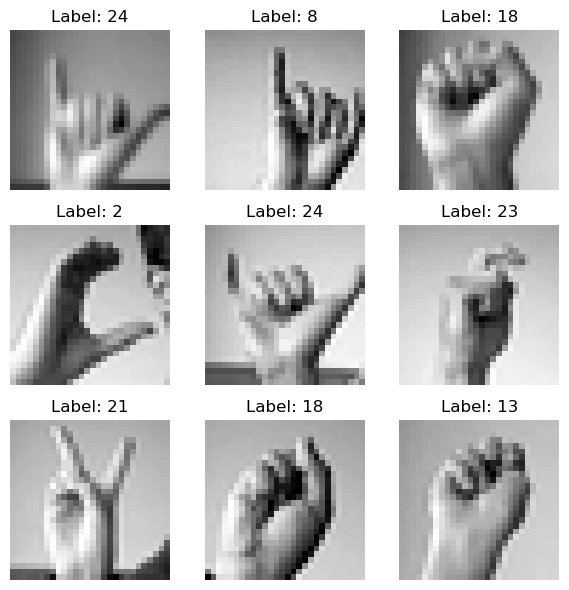

In [9]:
import matplotlib.pyplot as plt

# Pick 9 random samples
sample_df = train_df.sample(9, random_state=42)

plt.figure(figsize=(6, 6))
for i, (_, row) in enumerate(sample_df.iterrows()):
    img = row_to_image(row)
    label = row['label']
    plt.subplot(3, 3, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Label: {label}")
    plt.axis("off")
plt.tight_layout()
plt.show()

# Load Images from Folders

In [10]:
label_map = {
    0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E',
    5: 'F', 6: 'G', 7: 'H', 8: 'I', 10: 'K',
    11: 'L', 12: 'M', 13: 'N', 14: 'O', 15: 'P',
    16: 'Q', 17: 'R', 18: 'S', 19: 'T', 20: 'U',
    21: 'V', 22: 'W', 23: 'X', 24: 'Y'
}

# Preprocess train data

In [11]:
# Vectorized extraction of X and y
X = train_df.drop("label", axis=1).values.reshape(-1, 28, 28).astype(np.float32)
y = train_df["label"].map(label_map).values  # convert numeric → letter

In [12]:
print("X dtype before normalization:", X.dtype)

X dtype before normalization: float32


## Normalize + Train/Validation Split

In [13]:
# 2️⃣ Normalize only if needed
if X.max() > 1.0:
    X = X.astype(np.float32) / 255.0
else:
    X = X.astype(np.float32)  # just ensure float32 type

print("\nAfter normalization:")
print(f"X dtype: {X.dtype}, min: {X.min()}, max: {X.max()}")


After normalization:
X dtype: float32, min: 0.0, max: 1.0


# Preprocess test data

In [14]:
X_test = test_df.drop("label", axis=1).values.reshape(-1, 28, 28).astype(np.float32)
y_test = test_df["label"].map(label_map).values  # convert numeric -> letter

In [15]:
# Normalize
if X_test.max() > 1.0:
    X_test /= 255.0

In [16]:
print(f"✅ MNIST Test loaded: {X_test.shape}, Labels: {len(np.unique(y_test))}")
print(f"Pixel range: {X_test.min()} - {X_test.max()}")

✅ MNIST Test loaded: (7172, 28, 28), Labels: 24
Pixel range: 0.0 - 1.0


______________________________________________________________________________
# Second data
> ASL alphapet



In [17]:

# 1️⃣ Download ASL Alphabet dataset
asl_path = kagglehub.dataset_download("grassknoted/asl-alphabet")
print("Path to ASL dataset files:", asl_path)

Path to ASL dataset files: C:\Users\User\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1


In [18]:
asl_train_dir = "/root/.cache/kagglehub/datasets/grassknoted/asl-alphabet/versions/1/asl_alphabet_train/asl_alphabet_train"

In [19]:
# جمع كل أسماء الفولدرات (A..Y)
classes_asl = sorted([d for d in os.listdir(os.path.join(asl_path, 'asl_alphabet_train/asl_alphabet_train')) if os.path.isdir(os.path.join(asl_path, 'asl_alphabet_train/asl_alphabet_train', d))])
# إزالة الـ dynamic signs J,Z
classes_asl = [cls for cls in classes_asl if cls not in ["J", "Z"]]

X_asl, y_asl = [], []

for cls in classes_asl:
    folder = os.path.join(asl_path, 'asl_alphabet_train/asl_alphabet_train', cls)
    for file in os.listdir(folder):
        img_path = os.path.join(folder, file)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        # Resize to 28x28 like MNIST
        img = cv2.resize(img, (28, 28))
        X_asl.append(img)
        y_asl.append(cls)

X_asl = np.array(X_asl, dtype=np.float32)

In [20]:
# Normalize
if X_asl.max() > 1.0:
    X_asl /= 255.0

In [21]:
# Reshape to 4D for CNN
X_asl = X_asl.reshape(-1, 28, 28, 1)
y_asl = np.array(y_asl)

print(f"✅ ASL Loaded: {X_asl.shape}, Labels: {len(np.unique(y_asl))}")
print("Pixel range:", X_asl.min(), "-", X_asl.max())

✅ ASL Loaded: (81000, 28, 28, 1), Labels: 27
Pixel range: 0.0 - 1.0


In [22]:
# 3️⃣ Sanity Check before Merge
# =========================

print(f"MNIST: {X.shape}, Labels: {len(np.unique(y))}, Classes: {sorted(np.unique(y))[:5]} ...")
print(f"ASL:   {X_asl.shape}, Labels: {len(np.unique(y_asl))}, Classes: {sorted(np.unique(y_asl))[:5]} ...")

print(f"MNIST Pixel range: {X.min()} - {X.max()}")
print(f"ASL   Pixel range: {X_asl.min()} - {X_asl.max()}")

MNIST: (27455, 28, 28), Labels: 24, Classes: ['A', 'B', 'C', 'D', 'E'] ...
ASL:   (81000, 28, 28, 1), Labels: 27, Classes: [np.str_('A'), np.str_('B'), np.str_('C'), np.str_('D'), np.str_('E')] ...
MNIST Pixel range: 0.0 - 1.0
ASL   Pixel range: 0.0 - 1.0


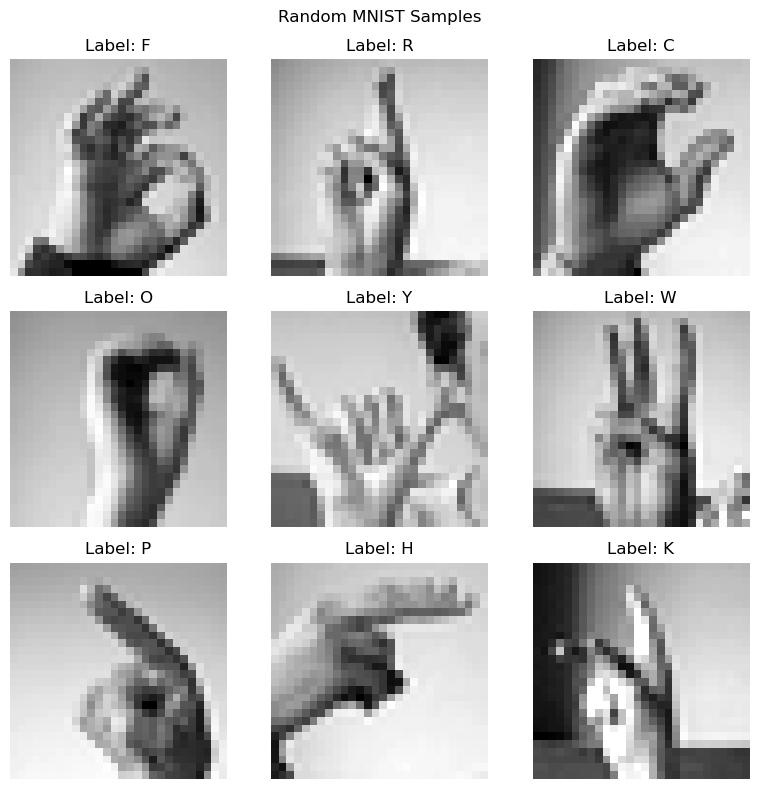

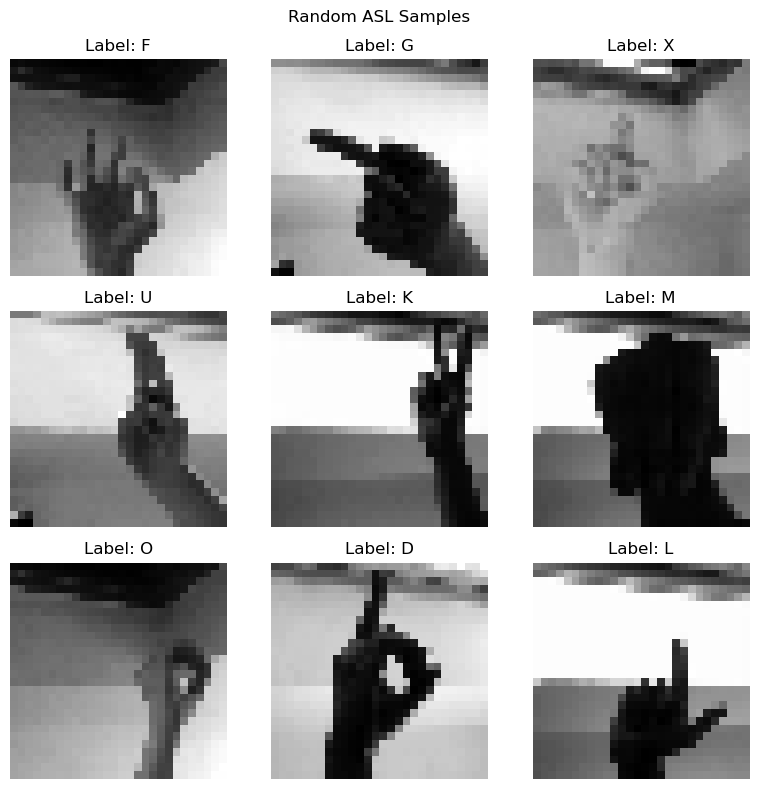

In [23]:
# Visualize few samples from MNIST
def visualize_samples(X, y, title, n=9):
    idxs = np.random.choice(len(X), n, replace=False)
    plt.figure(figsize=(8, 8))
    for i, idx in enumerate(idxs):
        plt.subplot(3, 3, i + 1)
        plt.imshow(X[idx].squeeze(), cmap="gray")
        plt.title(f"Label: {y[idx]}")
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

visualize_samples(X, y, "Random MNIST Samples", n=9)
visualize_samples(X_asl, y_asl, "Random ASL Samples", n=9)

# Merging the 2 datasets

In [24]:
# =========================
# 4️⃣ Merge MNIST + ASL
# =========================
X_full = np.concatenate([X.reshape(-1, 28, 28, 1), X_asl], axis=0)
y_full = np.concatenate([y, y_asl], axis=0)

print(f"🔄 Combined Dataset: {X_full.shape}, Labels: {len(y_full)}")

🔄 Combined Dataset: (108455, 28, 28, 1), Labels: 108455


In [25]:
# Build final classes
all_classes = sorted(np.unique(y_full))
class_to_idx = {cls: idx for idx, cls in enumerate(all_classes)}

# Encode labels to integers
y_full_encoded = np.array([class_to_idx[lbl] for lbl in y_full])

In [26]:
# 5️⃣ Train/Val/Test Split
# =========================
X_train, X_temp, y_train_idx, y_temp_idx = train_test_split(
    X_full, y_full_encoded, test_size=0.2, stratify=y_full_encoded, random_state=42
)

X_val, X_test, y_val_idx, y_test_idx = train_test_split(
    X_temp, y_temp_idx, test_size=0.5, stratify=y_temp_idx, random_state=42
)

In [27]:
# 6️⃣ One-hot Encoding
# =========================
num_classes = len(all_classes)
y_train = to_categorical(y_train_idx, num_classes=num_classes)
y_val = to_categorical(y_val_idx, num_classes=num_classes)
y_test = to_categorical(y_test_idx, num_classes=num_classes)

print(f"✅ Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}, Classes: {num_classes}")

✅ Train: (86764, 28, 28, 1), Val: (10845, 28, 28, 1), Test: (10846, 28, 28, 1), Classes: 27


# Step 3: Data Augmentation Pipeline

In [28]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
print("✅ TensorFlow ImageDataGenerator is available and working.")

✅ TensorFlow ImageDataGenerator is available and working.


In [29]:
datagen = ImageDataGenerator(
    rotation_range=10,        # تدوير بسيط ±10 درجات
    zoom_range=0.1,          # Zoom 10%
    width_shift_range=0.1,   # إزاحة أفقية 10%
    height_shift_range=0.1,  # إزاحة عمودية 10%
    shear_range=0.1,         # Shear بزاوية 10 درجات
    horizontal_flip=False,  
    vertical_flip=False,
    fill_mode='nearest'
)
# Fit generator on training data
datagen.fit(X_train)

print("✅ Augmentation pipeline fitted on training data.")

✅ Augmentation pipeline fitted on training data.


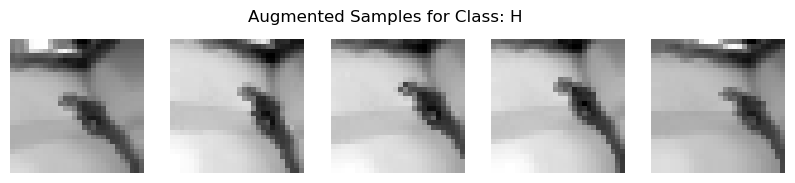

In [30]:
# 9️⃣ Visualization of Augmented Samples
sample_idx = np.random.randint(0, len(X_train))
x = X_train[sample_idx].reshape(1, 28, 28, 1)
true_label = all_classes[np.argmax(y_train[sample_idx])]

aug_iter = datagen.flow(x, batch_size=1)

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 2))
for i in range(5):
    batch = next(aug_iter)
    plt.subplot(1, 5, i + 1)
    plt.imshow(batch[0].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.suptitle(f"Augmented Samples for Class: {true_label}")
plt.show()

# Final check

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import collections

print("🔎 FINAL DATA CHECK BEFORE TRAINING")

# 1️⃣ Shapes
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"y shapes -> Train: {y_train.shape}, Val: {y_val.shape}, Test: {y_test.shape}")
print(f"Number of Classes: {len(all_classes)}, Classes: {all_classes}")

# 2️⃣ Pixel range check
print(f"Pixel range (Train): {X_train.min()} - {X_train.max()}")
print(f"Pixel range (ASL):   {X_asl.min()} - {X_asl.max()}")

🔎 FINAL DATA CHECK BEFORE TRAINING
Train: (86764, 28, 28, 1), Val: (10845, 28, 28, 1), Test: (10846, 28, 28, 1)
y shapes -> Train: (86764, 27), Val: (10845, 27), Test: (10846, 27)
Number of Classes: 27, Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'del', 'nothing', 'space']
Pixel range (Train): 0.0 - 1.0
Pixel range (ASL):   0.0 - 1.0


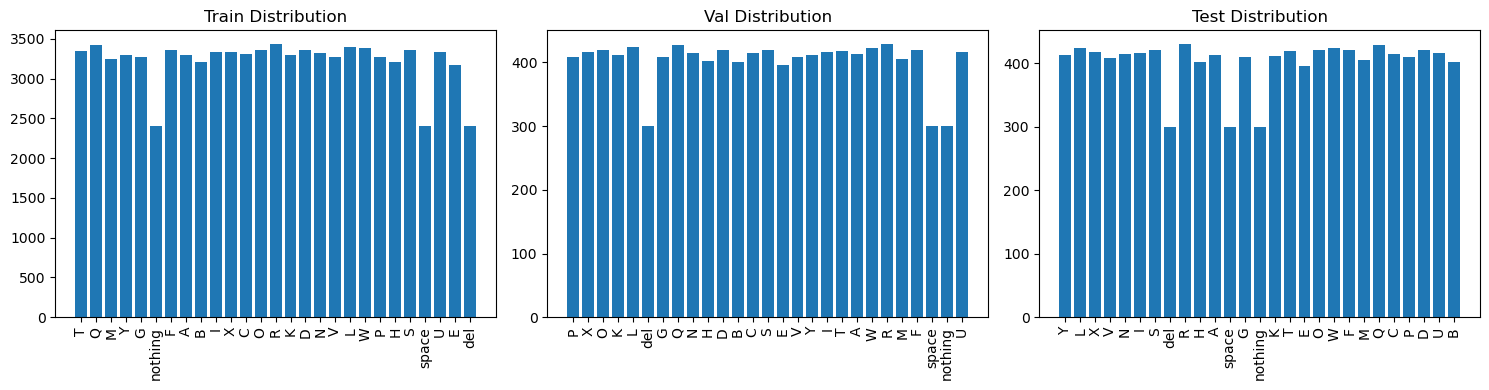

In [32]:
# 3️⃣ Class distribution check (Stratified?)
def plot_distribution(y_idx, title):
    counts = collections.Counter(y_idx)
    plt.bar([all_classes[i] for i in counts.keys()], counts.values())
    plt.title(title)
    plt.xticks(rotation=90)

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plot_distribution(np.argmax(y_train, axis=1), "Train Distribution")

plt.subplot(1, 3, 2)
plot_distribution(np.argmax(y_val, axis=1), "Val Distribution")

plt.subplot(1, 3, 3)
plot_distribution(np.argmax(y_test, axis=1), "Test Distribution")
plt.tight_layout()
plt.show()


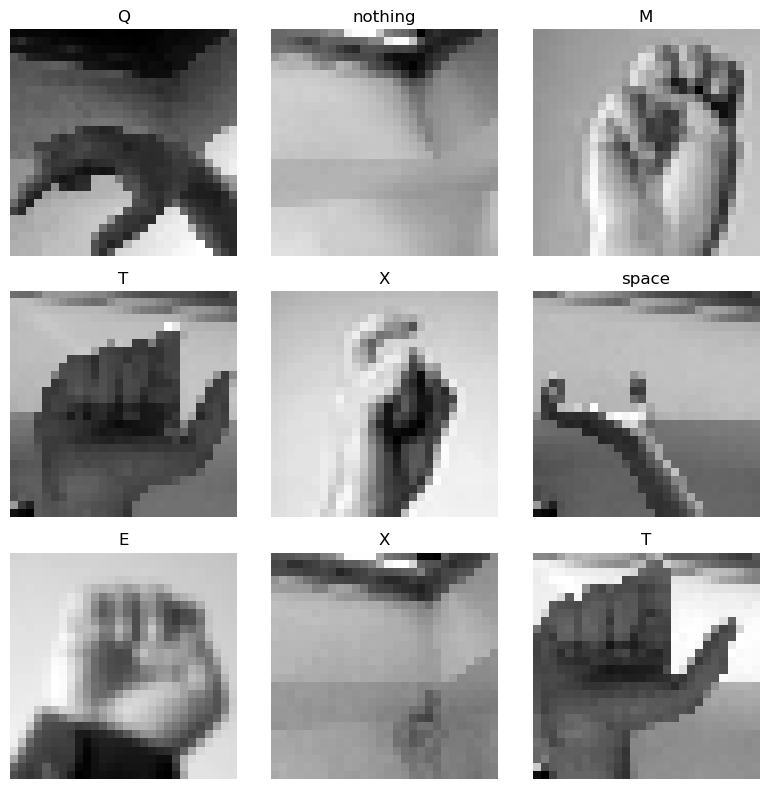

In [33]:
# 4️⃣ Sample visualization
def visualize_random_samples(X, y, classes, n=9):
    idxs = np.random.choice(len(X), n, replace=False)
    plt.figure(figsize=(8, 8))
    for i, idx in enumerate(idxs):
        plt.subplot(3, 3, i+1)
        plt.imshow(X[idx].squeeze(), cmap="gray")
        plt.title(classes[np.argmax(y[idx])])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

visualize_random_samples(X_train, y_train, all_classes, n=9)

# **Milestone 1 Finished successfully ✅**

# logistic regression

In [34]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import *
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns

In [35]:
X_train_ = X_train.reshape(X_train.shape[0], -1)
X_train_ = X_train_ / 255.0 
X_val_   = X_val.reshape(X_val.shape[0], -1)
X_val_ = X_val_ / 255.0 
X_test_  = X_test.reshape(X_test.shape[0], -1)
X_test_ = X_test_ / 255.0 


# y_train, y_val, y_test are one-hot -> convert back to indices
y_train_idx = np.argmax(y_train, axis=1)
y_val_idx = np.argmax(y_val, axis=1)
y_test_idx = np.argmax(y_test, axis=1)

In [36]:
# Logistic Regression model
model2 = LogisticRegression(max_iter=20000)
# solver="saga",n_jobs=-1 
model2.fit(X_train_, y_train_idx)

y_pred = model2.predict(X_test_)
train_acc = accuracy_score(y_train_idx, model2.predict(X_train_))
test_acc = accuracy_score(y_test_idx,y_pred )

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)
print(classification_report(y_test_idx, y_pred))

Train Accuracy: 0.14040385413305057
Test Accuracy: 0.13977503226996127
              precision    recall  f1-score   support

           0       0.09      0.26      0.14       412
           1       0.00      0.00      0.00       401
           2       0.26      0.58      0.36       414
           3       0.13      0.10      0.11       420
           4       0.00      0.00      0.00       395
           5       0.16      0.33      0.22       421
           6       0.17      0.22      0.19       409
           7       0.65      0.04      0.07       401
           8       0.12      0.05      0.07       416
           9       0.29      0.06      0.10       411
          10       0.16      0.57      0.25       424
          11       0.00      0.00      0.00       405
          12       0.32      0.20      0.24       415
          13       0.14      0.10      0.11       420
          14       0.19      0.12      0.15       409
          15       0.12      0.31      0.17       428
          

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


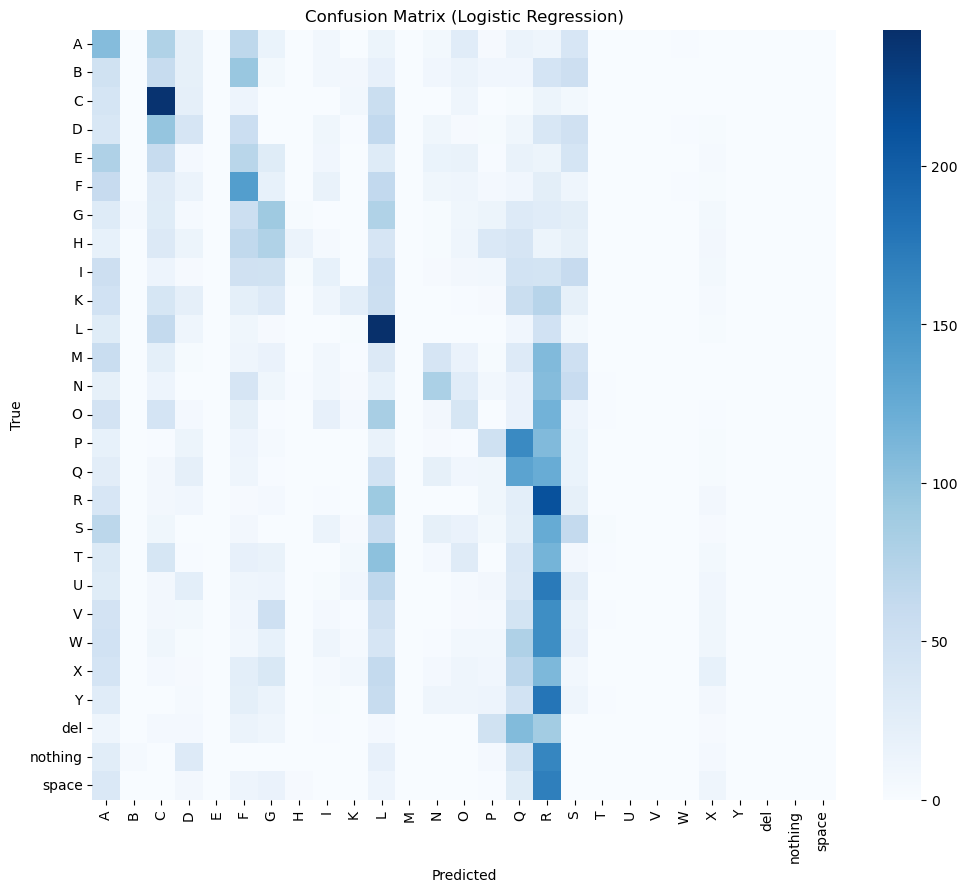

In [37]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

train_sizes, train_scores, val_scores = learning_curve(
    model2, X_train_, y_train_idx, cv=3 , scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 3)
)

train_gb_mean = train_scores.mean(axis=1)
val_gb_mean = val_scores.mean(axis=1)

train_gb_mean = train_scores.mean(axis=1)
val_gb_mean = val_scores.mean(axis=1)

cm = confusion_matrix(y_test_idx, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=all_classes, yticklabels=all_classes)
plt.title("Confusion Matrix (Logistic Regression)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# HistGradient Boosting

In [38]:
X_train_flat = X_train.reshape(len(X_train), -1)
X_val_flat   = X_val.reshape(len(X_val), -1)
X_test_flat  = X_test.reshape(len(X_test), -1)

y_train_idx = np.argmax(y_train, axis=1)
y_val_idx   = np.argmax(y_val, axis=1)
y_test_idx  = np.argmax(y_test, axis=1)

subset_size = 20000
X_train_sub = X_train_flat[:subset_size]
y_train_sub = y_train_idx[:subset_size]

In [39]:
from sklearn.ensemble import HistGradientBoostingClassifier

gb = HistGradientBoostingClassifier(
    max_iter=100,      # number of boosting iterations
    learning_rate=0.05,
    max_depth=10,
    random_state=42
)
gb.fit(X_train_sub, y_train_sub)

HistGradientBoostingClassifier(learning_rate=0.05, max_depth=10,
                               random_state=42)

In [40]:
#evaluate
y_pred1 = gb.predict(X_test_flat)
train_acc = accuracy_score(y_train_idx, gb.predict(X_train_flat))
test_acc = accuracy_score(y_test_idx,y_pred1 )

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)
print(classification_report(y_test_idx, y_pred))

Train Accuracy: 0.9540362362270066
Test Accuracy: 0.9474460630647243
              precision    recall  f1-score   support

           0       0.09      0.26      0.14       412
           1       0.00      0.00      0.00       401
           2       0.26      0.58      0.36       414
           3       0.13      0.10      0.11       420
           4       0.00      0.00      0.00       395
           5       0.16      0.33      0.22       421
           6       0.17      0.22      0.19       409
           7       0.65      0.04      0.07       401
           8       0.12      0.05      0.07       416
           9       0.29      0.06      0.10       411
          10       0.16      0.57      0.25       424
          11       0.00      0.00      0.00       405
          12       0.32      0.20      0.24       415
          13       0.14      0.10      0.11       420
          14       0.19      0.12      0.15       409
          15       0.12      0.31      0.17       428
          16

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


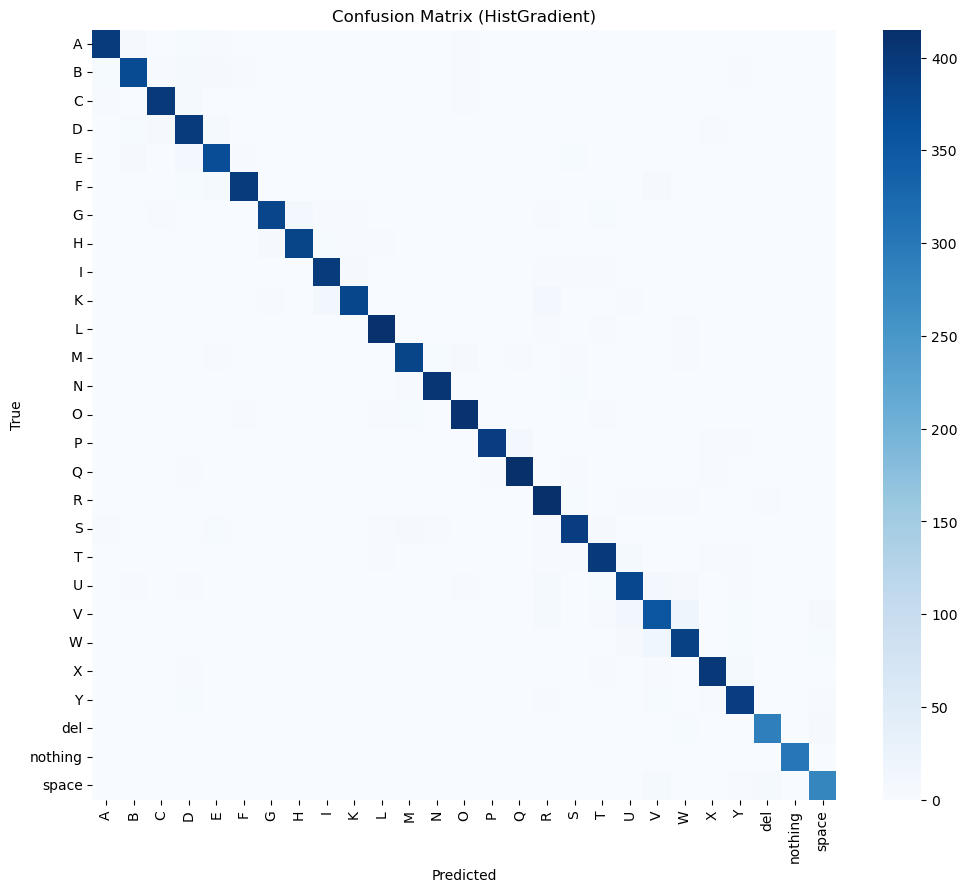

In [41]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np


train_gb_mean = train_scores.mean(axis=1)
val_gb_mean = val_scores.mean(axis=1)

cm = confusion_matrix(y_test_idx, y_pred1)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=all_classes, yticklabels=all_classes)
plt.title("Confusion Matrix (HistGradient)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Random forest

In [42]:
print("🔎 Training a simple ML model (Random Forest)...")

# 1️⃣ Flatten images
X_train_flat = X_train.reshape(len(X_train), -1)
X_val_flat = X_val.reshape(len(X_val), -1)
X_test_flat = X_test.reshape(len(X_test), -1)

# ⚠️ Training on full dataset may be slow → use subset for quick test
subset_size = 15000  # <= قلل أو زود لو عايز
X_train_sub = X_train_flat[:subset_size]
y_train_sub = np.argmax(y_train, axis=1)[:subset_size]

🔎 Training a simple ML model (Random Forest)...


In [43]:
# 2️⃣ Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,   # عدد الأشجار
    max_depth=None,     # بدون حد للعمق
    n_jobs=-1,          # استخدام كل المعالجات
    random_state=42
)
rf_model.fit(X_train_sub, y_train_sub)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [44]:
# 3️⃣ Evaluate
y_pred_val = rf_model.predict(X_val_flat)
val_acc = accuracy_score(np.argmax(y_val, axis=1), y_pred_val)
print(f"✅ Validation Accuracy: {val_acc:.4f}")

y_pred_test = rf_model.predict(X_test_flat)
test_acc = accuracy_score(np.argmax(y_test, axis=1), y_pred_test)
print(f"✅ Test Accuracy: {test_acc:.4f}")

# 4️⃣ Classification Report
print("\n📊 Classification Report:")
print(classification_report(np.argmax(y_test, axis=1), y_pred_test, target_names=all_classes))

✅ Validation Accuracy: 0.9296
✅ Test Accuracy: 0.9355

📊 Classification Report:
              precision    recall  f1-score   support

           A       0.93      0.96      0.94       412
           B       0.93      0.88      0.90       401
           C       0.97      0.94      0.96       414
           D       0.86      0.96      0.91       420
           E       0.90      0.93      0.92       395
           F       0.98      0.91      0.95       421
           G       0.95      0.95      0.95       409
           H       0.95      0.95      0.95       401
           I       0.92      0.94      0.93       416
           K       0.94      0.92      0.93       411
           L       0.96      0.96      0.96       424
           M       0.95      0.88      0.92       405
           N       0.93      0.97      0.95       415
           O       0.94      0.97      0.96       420
           P       0.97      0.97      0.97       409
           Q       0.97      0.97      0.97       428
 

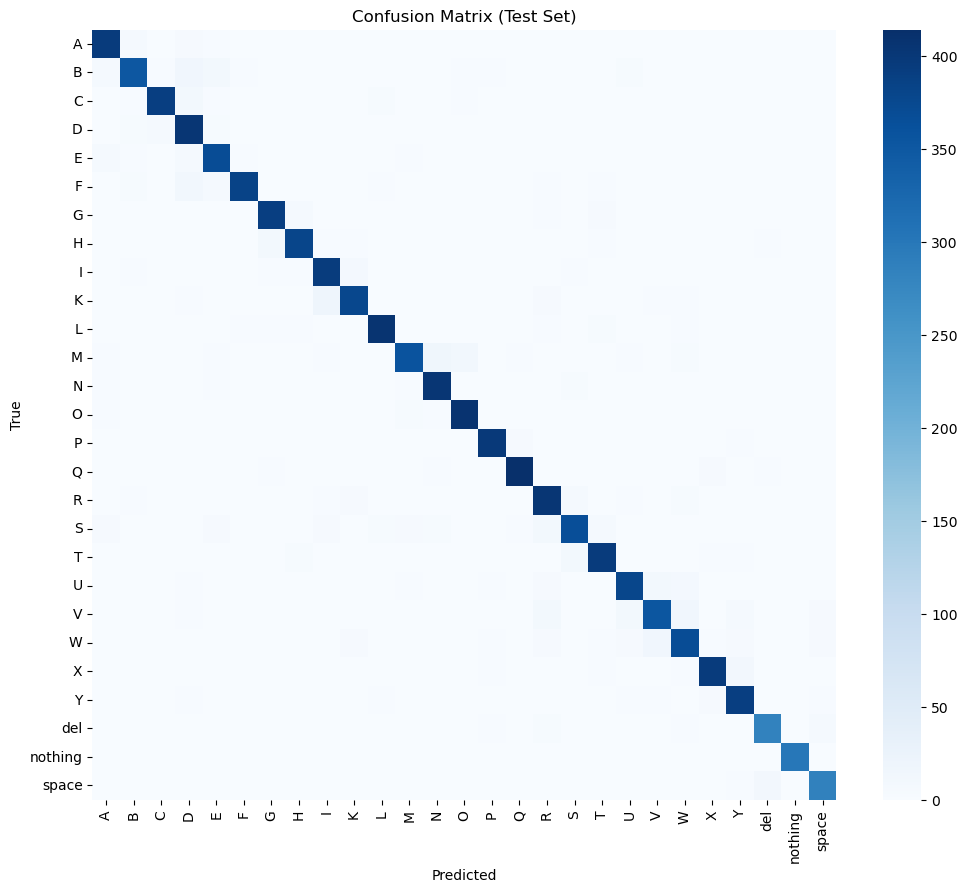

In [45]:
# 5️⃣ Confusion Matrix
cm = confusion_matrix(np.argmax(y_test, axis=1), y_pred_test)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=all_classes, yticklabels=all_classes)
plt.title("Confusion Matrix (Test Set)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# XG BOOST

In [46]:
import xgboost as xgb

In [47]:
print("🔎 Training a simple ML model (XGBoost)...")

# 1️⃣ Flatten data
X_train_flat = X_train.reshape(len(X_train), -1)
X_val_flat   = X_val.reshape(len(X_val), -1)
X_test_flat  = X_test.reshape(len(X_test), -1)

y_train_idx = np.argmax(y_train, axis=1)
y_val_idx   = np.argmax(y_val, axis=1)
y_test_idx  = np.argmax(y_test, axis=1)

# 2️⃣ استخدم subset للتجربة السريعة (اختياري)
subset_size = 20000
X_train_sub = X_train_flat[:subset_size]
y_train_sub = y_train_idx[:subset_size]

🔎 Training a simple ML model (XGBoost)...


In [48]:
# 3️⃣ XGBoost model
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    objective="multi:softmax",
    num_class=len(all_classes),
    tree_method="hist",  # أسرع على بيانات كبيرة
    n_jobs=-1,
    random_state=42
)

xgb_model.fit(X_train_sub, y_train_sub)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=-1, num_class=27, ...)

In [49]:
# 4️⃣ Evaluate
y_pred_test = xgb_model.predict(X_test_flat)
test_acc = accuracy_score(y_test_idx, y_pred_test)
print(f"✅ Test Accuracy: {test_acc:.4f}")

print("\n📊 Classification Report:")
print(classification_report(y_test_idx, y_pred_test, target_names=all_classes))

✅ Test Accuracy: 0.9539

📊 Classification Report:
              precision    recall  f1-score   support

           A       0.95      0.96      0.96       412
           B       0.93      0.94      0.93       401
           C       0.98      0.96      0.97       414
           D       0.93      0.96      0.94       420
           E       0.93      0.94      0.94       395
           F       0.98      0.93      0.95       421
           G       0.96      0.94      0.95       409
           H       0.96      0.97      0.96       401
           I       0.94      0.95      0.94       416
           K       0.96      0.93      0.95       411
           L       0.96      0.97      0.97       424
           M       0.98      0.94      0.96       405
           N       0.97      0.98      0.98       415
           O       0.96      0.98      0.97       420
           P       0.99      0.96      0.98       409
           Q       0.97      0.98      0.97       428
           R       0.91      0.

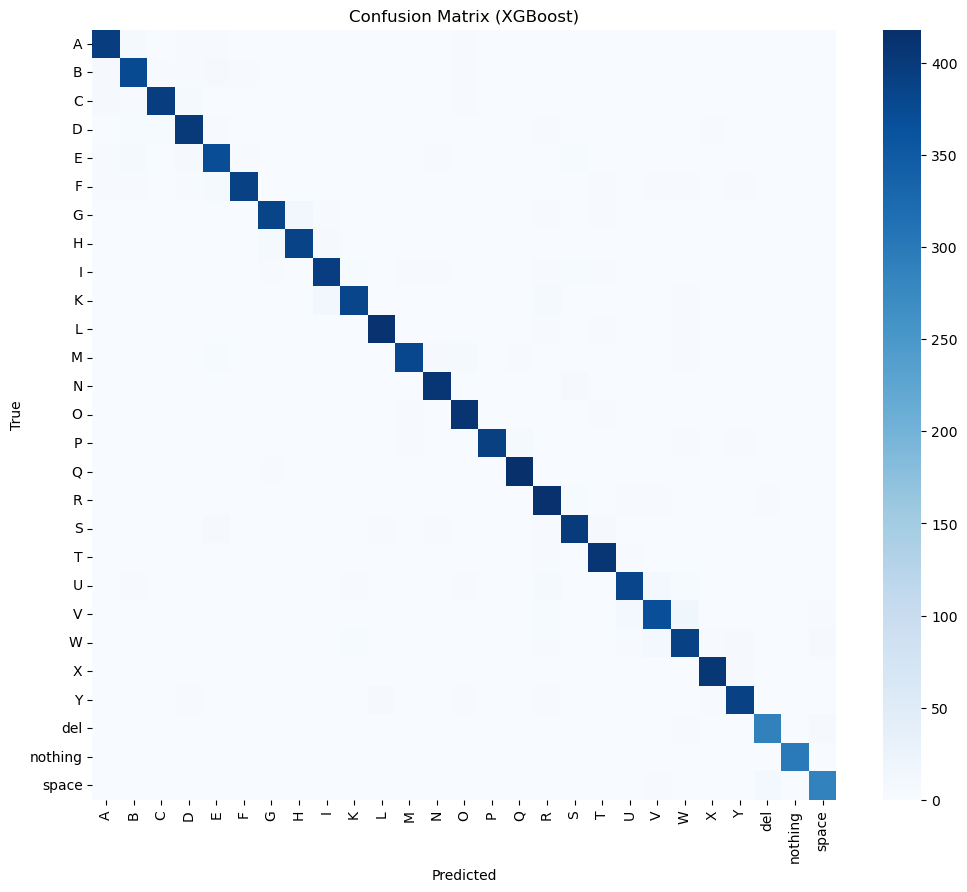

In [50]:
# 5️⃣ Confusion Matrix
cm = confusion_matrix(y_test_idx, y_pred_test)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=all_classes, yticklabels=all_classes)
plt.title("Confusion Matrix (XGBoost)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Simulate Real-Time

🔎 Simulating Real-Time Test with Augmented Images...
=== 📊 Results on Original & Augmented Test (Subset) ===
RandomForest -> Original: 0.9550, Augmented: 0.2850, Drop: 67.00%
XGBoost      -> Original: 0.9900, Augmented: 0.2500, Drop: 74.00%
HistGB        -> Original: 0.9800, Augmented: 0.2150, Drop: 76.50%


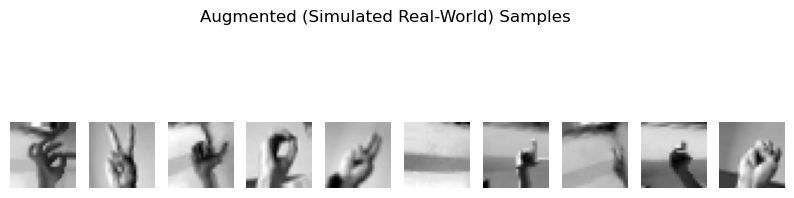

In [51]:
from sklearn.metrics import accuracy_score

print("🔎 Simulating Real-Time Test with Augmented Images...")

# 1️⃣ Pick a random subset from test set
subset_size = 200
indices = np.random.choice(len(X_test), subset_size, replace=False)
X_test_sub = X_test[indices]
y_test_sub = np.argmax(y_test, axis=1)[indices]

# 2️⃣ Apply augmentation (simulate real-world distortions)
augmentor = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.15,
    shear_range=0.15,
    fill_mode='nearest'
)

augmented_images = []
augmented_labels = []

for i in range(len(X_test_sub)):
    x = X_test_sub[i].reshape(1, 28, 28, 1)
    aug_iter = augmentor.flow(x, batch_size=1)
    batch = next(aug_iter)[0]
    augmented_images.append(batch)
    augmented_labels.append(y_test_sub[i])

augmented_images = np.array(augmented_images)
augmented_labels = np.array(augmented_labels)

# Flatten for ML models
X_test_sub_flat = X_test_sub.reshape(len(X_test_sub), -1)
augmented_images_flat = augmented_images.reshape(len(augmented_images), -1)

# 3️⃣ Evaluate RandomForest
rf_orig_acc = accuracy_score(y_test_sub, rf_model.predict(X_test_sub_flat))
rf_aug_acc = accuracy_score(augmented_labels, rf_model.predict(augmented_images_flat))

# 4️⃣ Evaluate XGBoost (if available)
xgb_orig_acc = accuracy_score(y_test_sub, xgb_model.predict(X_test_sub_flat))
xgb_aug_acc = accuracy_score(augmented_labels, xgb_model.predict(augmented_images_flat))

hgb_orig_acc = accuracy_score(y_test_sub, gb.predict(X_test_sub_flat))
hgb_aug_acc = accuracy_score(augmented_labels, gb.predict(augmented_images_flat))

# 5️⃣ Print results
print("=== 📊 Results on Original & Augmented Test (Subset) ===")
print(f"RandomForest -> Original: {rf_orig_acc:.4f}, Augmented: {rf_aug_acc:.4f}, Drop: {(rf_orig_acc - rf_aug_acc)*100:.2f}%")
print(f"XGBoost      -> Original: {xgb_orig_acc:.4f}, Augmented: {xgb_aug_acc:.4f}, Drop: {(xgb_orig_acc - xgb_aug_acc)*100:.2f}%")
print(f"HistGB        -> Original: {hgb_orig_acc:.4f}, Augmented: {hgb_aug_acc:.4f}, Drop: {(hgb_orig_acc - hgb_aug_acc)*100:.2f}%")


# 6️⃣ Show some augmented samples
plt.figure(figsize=(10, 3))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(augmented_images[i].squeeze(), cmap='gray')
    plt.axis("off")
plt.suptitle("Augmented (Simulated Real-World) Samples")
plt.show()


# **Definition of CNN model**

In [52]:
def create_cnn(input_shape, num_classes):
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
        layers.BatchNormalization(),   # Normalizes activations → stabilizes training
        layers.Dropout(0.25),   # Randomly drops 25% of neurons → reduces overfitting
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3), activation='relu'),
        layers.BatchNormalization(),  # Keeps activations stable across layers
        layers.Dropout(0.25),   # Regularization again to prevent overfitting
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(128, (3,3), activation='relu'),
        layers.BatchNormalization(),   # Helps model converge faster
        layers.MaxPooling2D((2,2)),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),  # Normalize before final output
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

input_shape = (28, 28, 1)
model = create_cnn(input_shape, num_classes)
model.summary()


C:\Users\User\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 26, 26, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 3, 3, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 27)             │         6,939 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,555 (525.61 KB)

 Trainable params: 133,595 (521.86 KB)

 Non-trainable params: 960 (3.75 KB)

#  Compile Model

In [53]:
from tensorflow.keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=1e-3),   #learning rate 0.001 (good balance of speed + stability)
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# **Callbacks**

In [54]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


checkpoint_cb = ModelCheckpoint("best_cnn_model.h5", save_best_only=True, monitor="val_accuracy", mode="max")
earlystop_cb = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr_cb = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6) #lets optimizer take smaller steps if stuck


# Model **training**

In [55]:
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=64),
    validation_data=(X_val, y_val),
    epochs=30,
    callbacks=[checkpoint_cb, earlystop_cb,reduce_lr_cb],
    verbose=1
)


Epoch 1/30


C:\Users\User\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1356/1356 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.2480 - loss: 2.8288 

1356/1356 ━━━━━━━━━━━━━━━━━━━━ 31s 21ms/step - accuracy: 0.3968 - loss: 2.0735 - val_accuracy: 0.5707 - val_loss: 2.0237 - learning_rate: 0.0010
Epoch 2/30
1355/1356 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6287 - loss: 1.1512 

1356/1356 ━━━━━━━━━━━━━━━━━━━━ 28s 21ms/step - accuracy: 0.6571 - loss: 1.0564 - val_accuracy: 0.7433 - val_loss: 0.7800 - learning_rate: 0.0010
Epoch 3/30
1354/1356 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7184 - loss: 0.8592 

...

1356/1356 ━━━━━━━━━━━━━━━━━━━━ 27s 20ms/step - accuracy: 0.8934 - loss: 0.3136 - val_accuracy: 0.9543 - val_loss: 0.1441 - learning_rate: 5.0000e-04
Epoch 16/30
1356/1356 ━━━━━━━━━━━━━━━━━━━━ 27s 20ms/step - accuracy: 0.8989 - loss: 0.2988 - val_accuracy: 0.9219 - val_loss: 0.2453 - learning_rate: 5.0000e-04
Epoch 17/30
1356/1356 ━━━━━━━━━━━━━━━━━━━━ 26s 19ms/step - accuracy: 0.9008 - loss: 0.2959 - val_accuracy: 0.9320 - val_loss: 0.2235 - learning_rate: 5.0000e-04
Epoch 18/30
1356/1356 ━━━━━━━━━━━━━━━━━━━━ 26s 19ms/step - accuracy: 0.9040 - loss: 0.2873 - val_accuracy: 0.9268 - val_loss: 0.2524 - learning_rate: 5.0000e-04
Epoch 19/30
1356/1356 ━━━━━━━━━━━━━━━━━━━━ 27s 20ms/step - accuracy: 0.9113 - loss: 0.2630 - val_accuracy: 0.9485 - val_loss: 0.1568 - learning_rate: 2.5000e-04
Epoch 20/30
1355/1356 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9143 - loss: 0.2524 

1356/1356 ━━━━━━━━━━━━━━━━━━━━ 27s 20ms/step - accuracy: 0.9142 - loss: 0.2549 - val_accuracy: 0.9644 - val_loss: 0.1120 - learning_rate: 2.5000e-04
Epoch 21/30
1354/1356 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9152 - loss: 0.2490 

1356/1356 ━━━━━━━━━━━━━━━━━━━━ 27s 20ms/step - accuracy: 0.9151 - loss: 0.2507 - val_accuracy: 0.9678 - val_loss: 0.1080 - learning_rate: 2.5000e-04
Epoch 22/30
1356/1356 ━━━━━━━━━━━━━━━━━━━━ 26s 20ms/step - accuracy: 0.9174 - loss: 0.2434 - val_accuracy: 0.9652 - val_loss: 0.1039 - learning_rate: 2.5000e-04
Epoch 23/30
1356/1356 ━━━━━━━━━━━━━━━━━━━━ 27s 20ms/step - accuracy: 0.9193 - loss: 0.2412 - val_accuracy: 0.9600 - val_loss: 0.1287 - learning_rate: 2.5000e-04
Epoch 24/30
1356/1356 ━━━━━━━━━━━━━━━━━━━━ 27s 20ms/step - accuracy: 0.9185 - loss: 0.2399 - val_accuracy: 0.9485 - val_loss: 0.1576 - learning_rate: 2.5000e-04
Epoch 25/30
1356/1356 ━━━━━━━━━━━━━━━━━━━━ 27s 20ms/step - accuracy: 0.9184 - loss: 0.2377 - val_accuracy: 0.9655 - val_loss: 0.1013 - learning_rate: 2.5000e-04
Epoch 26/30
1356/1356 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9210 - loss: 0.2361 

1356/1356 ━━━━━━━━━━━━━━━━━━━━ 27s 20ms/step - accuracy: 0.9201 - loss: 0.2361 - val_accuracy: 0.9686 - val_loss: 0.0957 - learning_rate: 2.5000e-04
Epoch 27/30
1356/1356 ━━━━━━━━━━━━━━━━━━━━ 27s 20ms/step - accuracy: 0.9208 - loss: 0.2313 - val_accuracy: 0.9604 - val_loss: 0.1290 - learning_rate: 2.5000e-04
Epoch 28/30
1356/1356 ━━━━━━━━━━━━━━━━━━━━ 27s 20ms/step - accuracy: 0.9232 - loss: 0.2284 - val_accuracy: 0.9666 - val_loss: 0.1120 - learning_rate: 2.5000e-04
Epoch 29/30
1356/1356 ━━━━━━━━━━━━━━━━━━━━ 27s 20ms/step - accuracy: 0.9233 - loss: 0.2280 - val_accuracy: 0.9619 - val_loss: 0.1162 - learning_rate: 2.5000e-04
Epoch 30/30
1356/1356 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9255 - loss: 0.2212 

1356/1356 ━━━━━━━━━━━━━━━━━━━━ 27s 20ms/step - accuracy: 0.9264 - loss: 0.2161 - val_accuracy: 0.9733 - val_loss: 0.0835 - learning_rate: 1.2500e-04


# Model **evaluation**

In [56]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"✅ Test Accuracy: {test_acc:.4f}")


✅ Test Accuracy: 0.9751


339/339 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step   

Classification Report:
               precision    recall  f1-score   support

           A       0.98      0.95      0.97       412
           B       0.96      0.98      0.97       401
           C       1.00      1.00      1.00       414
           D       0.99      0.99      0.99       420
           E       0.98      0.97      0.98       395
           F       1.00      1.00      1.00       421
           G       0.98      0.99      0.99       409
           H       0.99      0.99      0.99       401
           I       0.97      0.98      0.97       416
           K       0.97      0.99      0.98       411
           L       1.00      0.99      0.99       424
           M       0.97      0.92      0.94       405
           N       0.90      0.98      0.94       415
           O       0.98      0.98      0.98       420
           P       1.00      0.99      1.00       409
           Q       1.00      1.00      1.00       428
           R

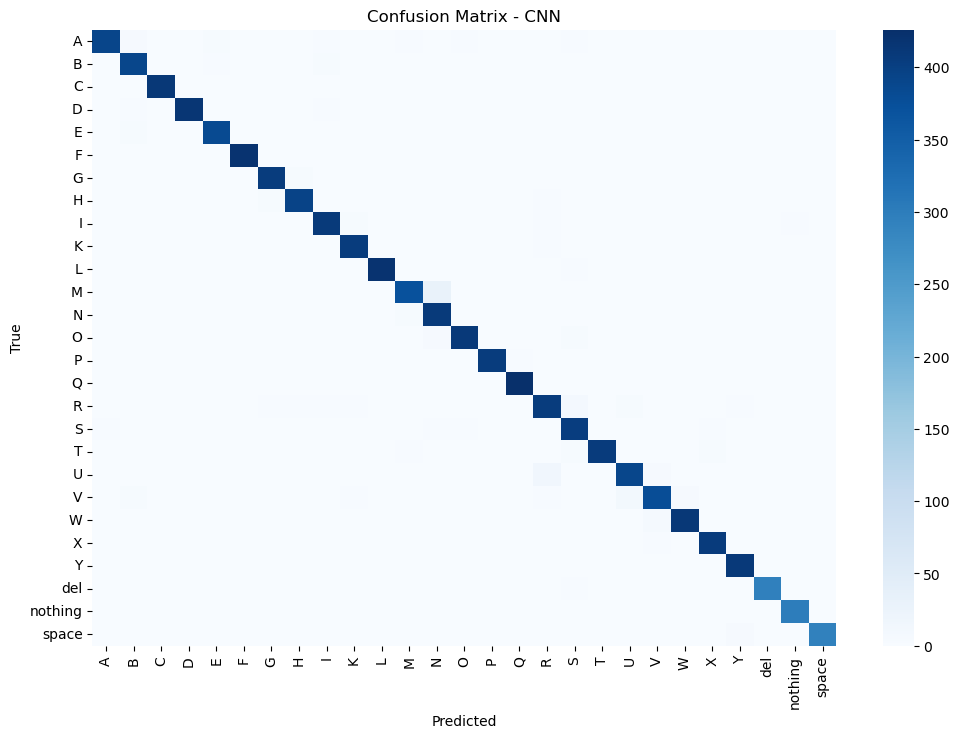

In [57]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print("\nClassification Report:\n", classification_report(y_true, y_pred_classes, target_names=all_classes))

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=all_classes, yticklabels=all_classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - CNN")
plt.show()


# Confusion Matrix + Classification **Report**

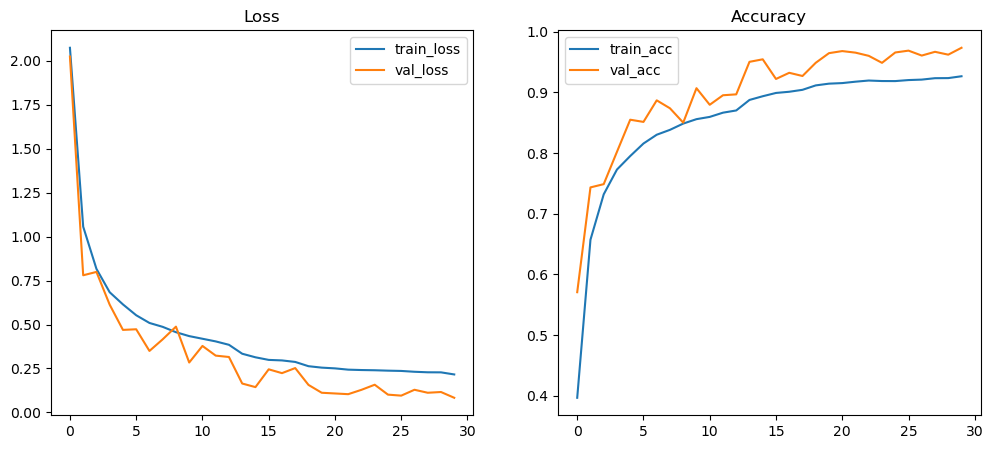

In [58]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend(); plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend(); plt.title("Accuracy")

plt.show()


# Real_Time Simulate for THE CNN

🔎 Simulating Real-Time Test for CNN Model...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
=== 📊 CNN Results on Original & Augmented Test (Subset) ===
CNN -> Original: 0.9750, Augmented: 0.9100, Drop: 6.50%


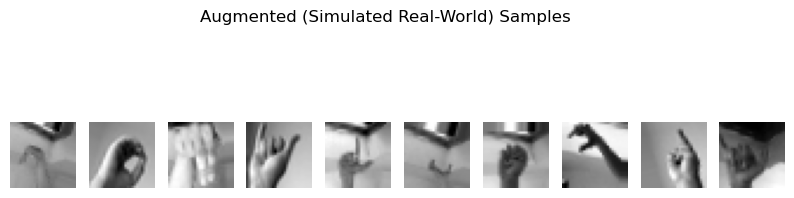

In [115]:
print("🔎 Simulating Real-Time Test for CNN Model...")

# 1️⃣ Pick a random subset from test set
subset_size = 200
indices = np.random.choice(len(X_test), subset_size, replace=False)
X_test_sub = X_test[indices]
y_test_sub = np.argmax(y_test, axis=1)[indices]  # one-hot to labels

# 2️⃣ Apply augmentation (simulate real-world distortions)
augmentor = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.15,
    shear_range=0.15,
    fill_mode='nearest'
)

augmented_images = []
augmented_labels = []

for i in range(len(X_test_sub)):
    x = X_test_sub[i].reshape(1, 28, 28, 1)   # adjust shape if not grayscale
    aug_iter = augmentor.flow(x, batch_size=1)
    batch = next(aug_iter)[0]
    augmented_images.append(batch)
    augmented_labels.append(y_test_sub[i])

augmented_images = np.array(augmented_images)
augmented_labels = np.array(augmented_labels)

# 3️⃣ Evaluate CNN model
cnn_orig_pred = np.argmax(model.predict(X_test_sub), axis=1)
cnn_aug_pred  = np.argmax(model.predict(augmented_images), axis=1)

cnn_orig_acc = accuracy_score(y_test_sub, cnn_orig_pred)
cnn_aug_acc  = accuracy_score(augmented_labels, cnn_aug_pred)

# 4️⃣ Print results
print("=== 📊 CNN Results on Original & Augmented Test (Subset) ===")
print(f"CNN -> Original: {cnn_orig_acc:.4f}, Augmented: {cnn_aug_acc:.4f}, Drop: {(cnn_orig_acc - cnn_aug_acc)*100:.2f}%")

# 5️⃣ Show some augmented samples
plt.figure(figsize=(10, 3))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(augmented_images[i].squeeze(), cmap='gray')
    plt.axis("off")
plt.suptitle("Augmented (Simulated Real-World) Samples")
plt.show()